In [1]:
#import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Load & Overview

In [2]:
credit_app = pd.read_csv(r"C:\Users\opeye\Documents\Developer\Python\FinRisk\FinRisk-ai-internship\data_source\credit_applications.csv")
credit_bd = pd.read_csv(r"C:\Users\opeye\Documents\Developer\Python\FinRisk\FinRisk-ai-internship\data_source\credit_bureau_data.csv")
customer_profiles = pd.read_csv(r"C:\Users\opeye\Documents\Developer\Python\FinRisk\FinRisk-ai-internship\data_source\customer_profiles.csv")
model_predictions = pd.read_csv(r"C:\Users\opeye\Documents\Developer\Python\FinRisk\FinRisk-ai-internship\data_source\model_predictions.csv")
transaction_data = pd.read_csv(r"C:\Users\opeye\Documents\Developer\Python\FinRisk\FinRisk-ai-internship\data_source\transaction_data.csv")

In [56]:
#viewing the first 5 rows of each dataset
print("Credit Applications:")
print(credit_app.head())
print("\nCredit Bureau Data:")
print(credit_bd.head())
print("\nCustomer Profiles:")
print(customer_profiles.head())
print("\nModel Predictions:")
print(model_predictions.head())
print("\nTransaction Data:")    
print(transaction_data.head())


Credit Applications:
  application_id  customer_id application_date  loan_amount   loan_purpose  \
0    APP_0000001  CUST_008172       2023-09-03       164883  Home Purchase   
1    APP_0000002  CUST_016851       2023-05-02        59782  Home Purchase   
2    APP_0000003  CUST_016766       2024-08-08        23716   Car Purchase   
3    APP_0000004  CUST_018679       2024-07-22        13514   Car Purchase   
4    APP_0000005  CUST_019411       2024-08-13        13992   Car Purchase   

  employment_status  annual_income  debt_to_income_ratio  credit_score  \
0           Retired       85399.18                 0.828           675   
1         Full-time       20582.50                 1.005           677   
2         Part-time       11860.21                 0.694           732   
3         Part-time       16490.54                 0.710           850   
4         Part-time        9600.00                 0.530           630   

  application_status  default_flag  
0           Declined        

In [57]:
# checkdata structire and types
credit_app.info()
credit_bd.info()
customer_profiles.info()
model_predictions.info()
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   application_id        100000 non-null  object 
 1   customer_id           100000 non-null  object 
 2   application_date      100000 non-null  object 
 3   loan_amount           100000 non-null  int64  
 4   loan_purpose          100000 non-null  object 
 5   employment_status     100000 non-null  object 
 6   annual_income         100000 non-null  float64
 7   debt_to_income_ratio  100000 non-null  float64
 8   credit_score          100000 non-null  int64  
 9   application_status    100000 non-null  object 
 10  default_flag          100000 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 8.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  

In [58]:
#check for missing values
print("\nMissing values in Credit Applications:")
print(credit_app.isnull().sum())
print("\nMissing values in Credit Bureau Data:")
print(credit_bd.isnull().sum())
print("\nMissing values in Customer Profiles:")
print(customer_profiles.isnull().sum())
print("\nMissing values in Model Predictions:")
print(model_predictions.isnull().sum())
print("\nMissing values in Transaction Data:")
print(transaction_data.isnull().sum())


Missing values in Credit Applications:
application_id          0
customer_id             0
application_date        0
loan_amount             0
loan_purpose            0
employment_status       0
annual_income           0
debt_to_income_ratio    0
credit_score            0
application_status      0
default_flag            0
dtype: int64

Missing values in Credit Bureau Data:
customer_id              0
credit_score             0
credit_history_length    0
number_of_accounts       0
total_credit_limit       0
credit_utilization       0
payment_history          0
public_records           0
credit_score_quartile    0
dtype: int64

Missing values in Customer Profiles:
customer_id           0
customer_age          0
annual_income         0
employment_status     0
account_tenure        0
product_holdings      0
relationship_value    0
risk_segment          0
behavioral_score      0
credit_score          0
city                  0
last_activity_date    0
dtype: int64

Missing values in Model Pr

## EDA PHASE

### EDA For Model Prediction

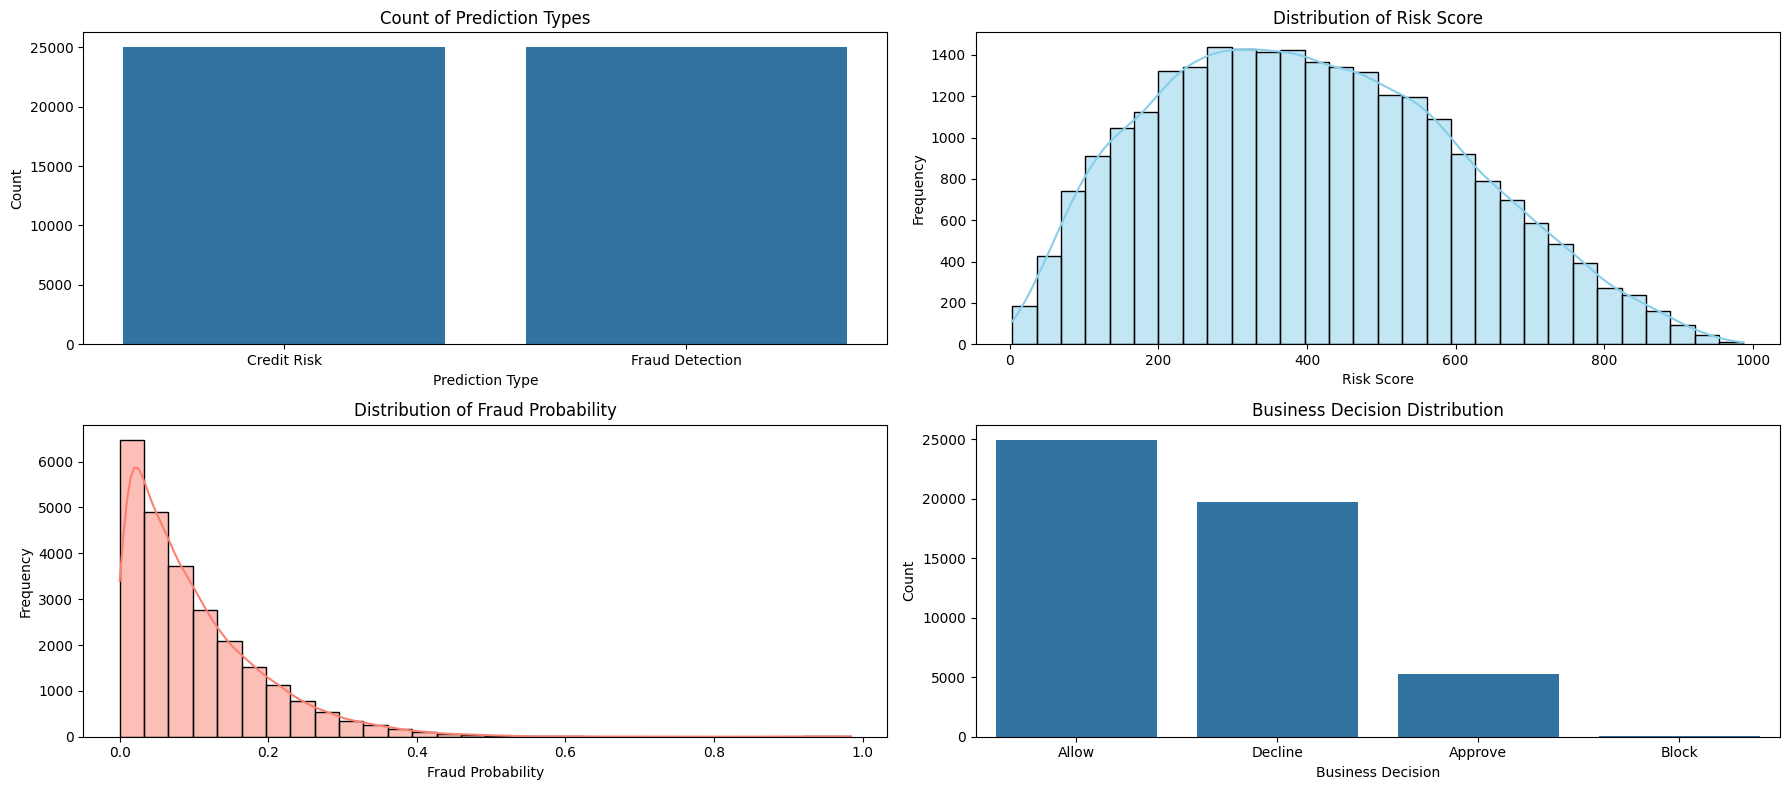

In [6]:


# Création d'une figure avec plusieurs visualisations
fig, axs = plt.subplots(2, 2, figsize=(18, 8))

#Chart 1: Count of Each Prediction Type
sns.countplot(data= model_predictions , x="prediction_type", ax=axs[0, 0])
axs[0, 0].set_title("Count of Prediction Types")
axs[0, 0].set_xlabel("Prediction Type")
axs[0, 0].set_ylabel("Count")

# Chart 2: Distribution of Risk Scores
sns.histplot(model_predictions["risk_score"].dropna(), bins=30, kde=True, ax=axs[0, 1], color="skyblue")
axs[0, 1].set_title("Distribution of Risk Score")
axs[0, 1].set_xlabel("Risk Score")
axs[0, 1].set_ylabel("Frequency")

# Chart 3: Distribution of Fraud Probabilities
sns.histplot(model_predictions["fraud_probability"].dropna(), bins=30, kde=True, ax=axs[1, 0], color="salmon")
axs[1, 0].set_title("Distribution of Fraud Probability")
axs[1, 0].set_xlabel("Fraud Probability")
axs[1, 0].set_ylabel("Frequency")

# Chart 4: Distribution of Business Decisions
sns.countplot(data= model_predictions, x="business_decision", ax=axs[1, 1], order=model_predictions["business_decision"].value_counts().index)
axs[1, 1].set_title("Business Decision Distribution")
axs[1, 1].set_xlabel("Business Decision")
axs[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### EDA for Credit Application

In [7]:
credit_app.head()

,application_id,customer_id,application_date,loan_amount,loan_purpose,employment_status,annual_income,debt_to_income_ratio,credit_score,application_status,default_flag
0,APP_0000001,CUST_008172,2023-09-03,164883,Home Purchase,Retired,85399.18,0.828,675,Declined,0
1,APP_0000002,CUST_016851,2023-05-02,59782,Home Purchase,Full-time,20582.50,1.005,677,Declined,0
2,APP_0000003,CUST_016766,2024-08-08,23716,Car Purchase,Part-time,11860.21,0.694,732,Declined,0
3,APP_0000004,CUST_018679,2024-07-22,13514,Car Purchase,Part-time,16490.54,0.710,850,Declined,0
4,APP_0000005,CUST_019411,2024-08-13,13992,Car Purchase,Part-time,9600.00,0.530,630,Declined,0


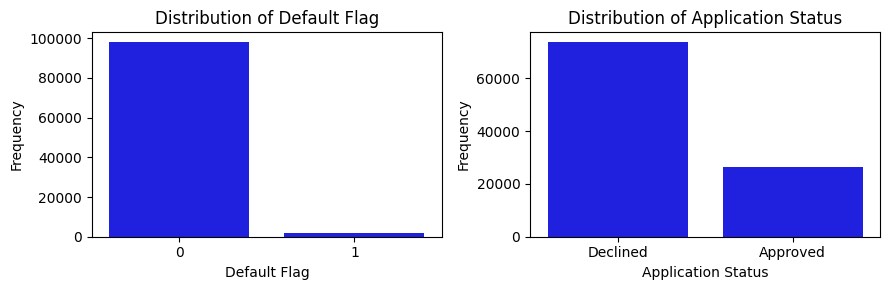

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

# 1. Default Flag
sns.countplot(x=credit_app['default_flag'].dropna(), color='blue', ax=axes[0])
axes[0].set_title('Distribution of Default Flag')
axes[0].set_xlabel('Default Flag')
axes[0].set_ylabel('Frequency')

# 2. Application Status
sns.countplot(x=credit_app['application_status'].dropna(), color='blue', ax=axes[1])
axes[1].set_title('Distribution of Application Status')
axes[1].set_xlabel('Application Status')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

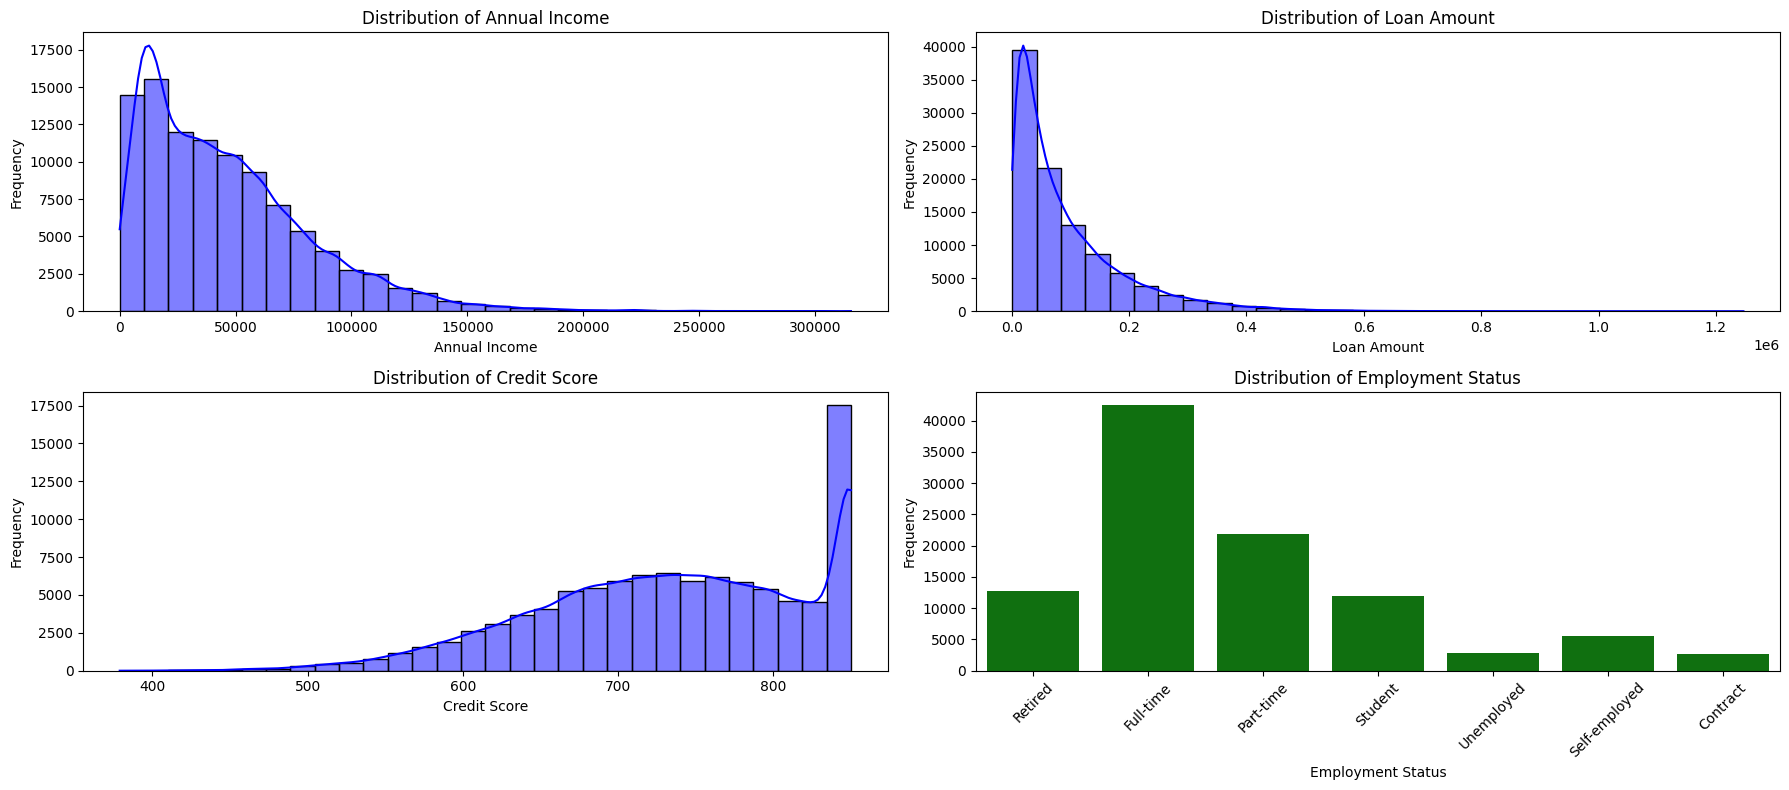

In [25]:
# Create subplots (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# 1. Annual Income
sns.histplot(credit_app['annual_income'].dropna(), bins=30, kde=True, color='blue', ax=axes[0,0])
axes[0,0].set_title('Distribution of Annual Income')
axes[0,0].set_xlabel('Annual Income')
axes[0,0].set_ylabel('Frequency')

# 2. Loan Amount
sns.histplot(credit_app['loan_amount'].dropna(), bins=30, kde=True, color='blue', ax=axes[0,1])
axes[0,1].set_title('Distribution of Loan Amount')
axes[0,1].set_xlabel('Loan Amount')
axes[0,1].set_ylabel('Frequency')

# 3. Credit Score
sns.histplot(credit_app['credit_score'].dropna(), bins=30, kde=True, color='blue', ax=axes[1,0])
axes[1,0].set_title('Distribution of Credit Score')
axes[1,0].set_xlabel('Credit Score')
axes[1,0].set_ylabel('Frequency')

# 4. Employment Status (bar chart)
sns.countplot(x=credit_app['employment_status'].dropna(), color='green', ax=axes[1,1])
axes[1,1].set_title('Distribution of Employment Status')
axes[1,1].set_xlabel('Employment Status')
axes[1,1].set_ylabel('Frequency')
axes[1,1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

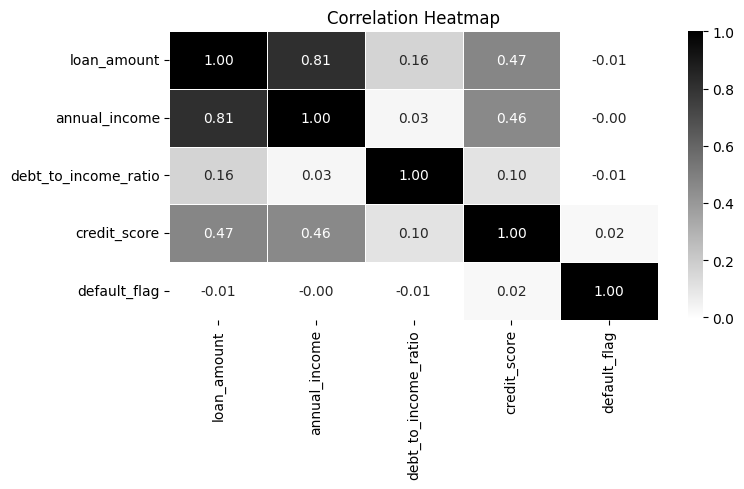

In [42]:
# Select numeric columns for correlation
corr_cols = ['loan_amount', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'default_flag']
corr = credit_app[corr_cols].corr()


# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='binary', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### EDA for Credit Bureau Data

In [29]:
credit_bd.head()

,customer_id,credit_score,credit_history_length,number_of_accounts,total_credit_limit,credit_utilization,payment_history,public_records
0,CUST_000001,742,21,4,7901,0.303,0.912,0
1,CUST_000002,565,3,2,3545,0.730,0.644,0
2,CUST_000003,754,10,3,43267,0.168,0.965,0
3,CUST_000004,792,47,1,40709,0.002,0.980,0
4,CUST_000005,850,10,4,41860,0.012,0.956,0


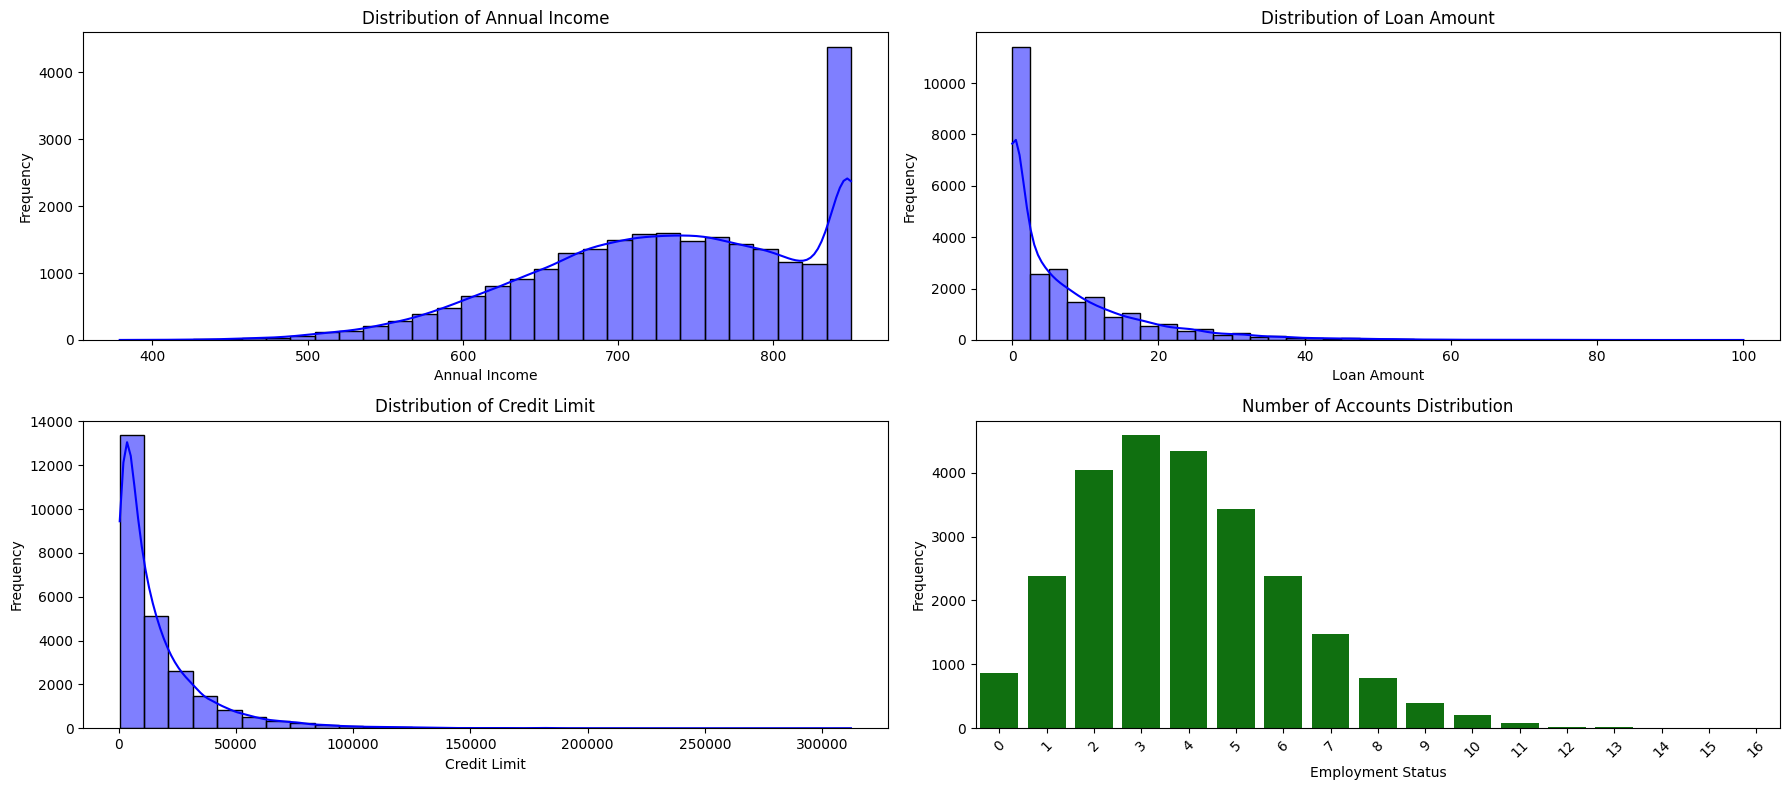

In [32]:
# Create subplots (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# 1. Annual Income
sns.histplot(credit_bd['credit_score'].dropna(), bins=30, kde=True, color='blue', ax=axes[0,0])
axes[0,0].set_title('Distribution of Annual Income')
axes[0,0].set_xlabel('Annual Income')
axes[0,0].set_ylabel('Frequency')

# 2. Loan Amount
sns.histplot(credit_bd['credit_history_length'].dropna(), bins=40, kde=True, color='blue', ax=axes[0,1])
axes[0,1].set_title('Distribution of Loan Amount')
axes[0,1].set_xlabel('Loan Amount')
axes[0,1].set_ylabel('Frequency')

# 3. Credit Score
sns.histplot(credit_bd['total_credit_limit'].dropna(), bins=30, kde=True, color='blue', ax=axes[1,0])
axes[1,0].set_title('Distribution of Credit Limit')
axes[1,0].set_xlabel('Credit Limit')
axes[1,0].set_ylabel('Frequency')

# 4. Employment Status (bar chart)
sns.countplot(x=credit_bd['number_of_accounts'].dropna(), color='green', ax=axes[1,1])
axes[1,1].set_title('Number of Accounts Distribution')
axes[1,1].set_xlabel('Employment Status')
axes[1,1].set_ylabel('Frequency')
axes[1,1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

C:\Users\opeye\AppData\Local\Temp\ipykernel_24488\3567696881.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_score_quartile', y='credit_utilization', data=credit_bd, palette="Blues" ,ax=axes[1])


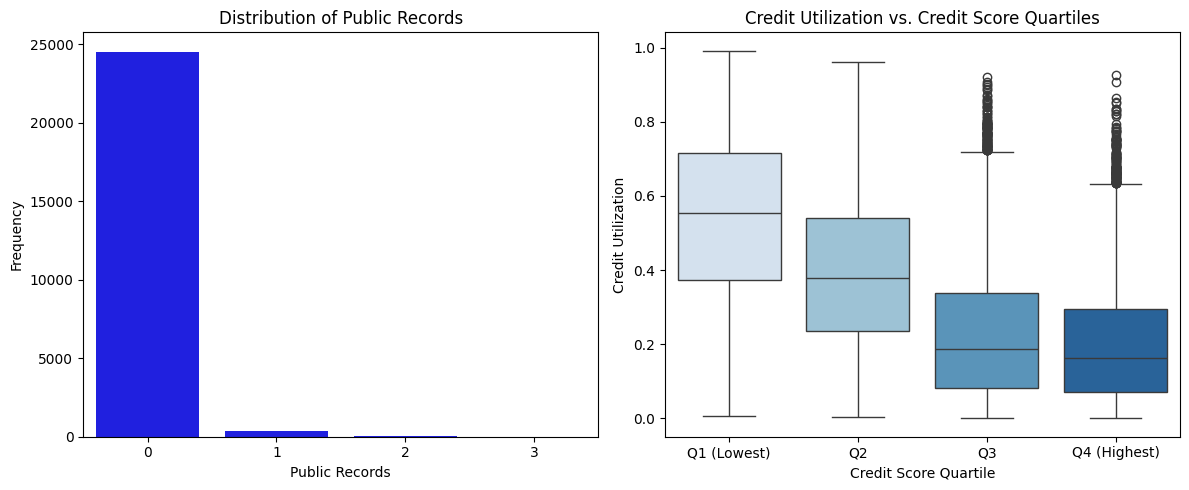

In [36]:

credit_bd['credit_score_quartile'] = pd.qcut(
                                            credit_bd['credit_score'], 
                                            q=4, 
                                            labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
)

# Create subplot (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Countplot of Public Records
sns.countplot(x=credit_bd['public_records'], color='blue', ax=axes[0])
axes[0].set_title('Distribution of Public Records')
axes[0].set_xlabel('Public Records')
axes[0].set_ylabel('Frequency')

# 2. Boxplot Credit Utilization vs. Credit Score Quartiles
sns.boxplot(x='credit_score_quartile', y='credit_utilization', data=credit_bd, palette="Blues" ,ax=axes[1])
axes[1].set_title("Credit Utilization vs. Credit Score Quartiles")
axes[1].set_xlabel("Credit Score Quartile")
axes[1].set_ylabel("Credit Utilization")

# Adjust layout
plt.tight_layout()
plt.show()

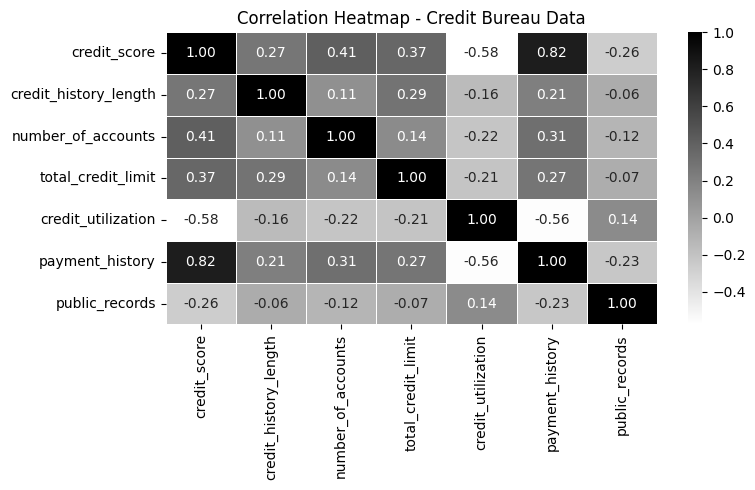

In [43]:

# Select numeric columns for correlation
corr_cols = ['credit_score', 'credit_history_length', 'number_of_accounts',
             'total_credit_limit', 'credit_utilization', 'payment_history', 'public_records']

# Compute correlation matrix
corr = credit_bd[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='binary', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - Credit Bureau Data")
plt.tight_layout()
plt.show()

### EDA for Customer Profile

In [40]:
customer_profiles.head()

,customer_id,customer_age,annual_income,employment_status,account_tenure,product_holdings,relationship_value,risk_segment,behavioral_score,credit_score,city,last_activity_date
0,CUST_000001,47,57726.04,Full-time,2,2,13854.25,Near-Prime,221.73,742,Newcastle,2025-07-14
1,CUST_000002,22,37938.40,Full-time,3,2,9863.98,Subprime,586.23,565,Birmingham,2025-07-10
2,CUST_000003,37,68477.75,Self-employed,2,5,41086.65,Prime,23.43,754,Liverpool,2025-07-22
3,CUST_000004,71,94196.78,Retired,5,5,70647.59,Prime,484.24,792,Manchester,2025-07-20
4,CUST_000005,54,65625.57,Full-time,5,2,19687.67,Prime,274.00,850,Bristol,2025-07-19


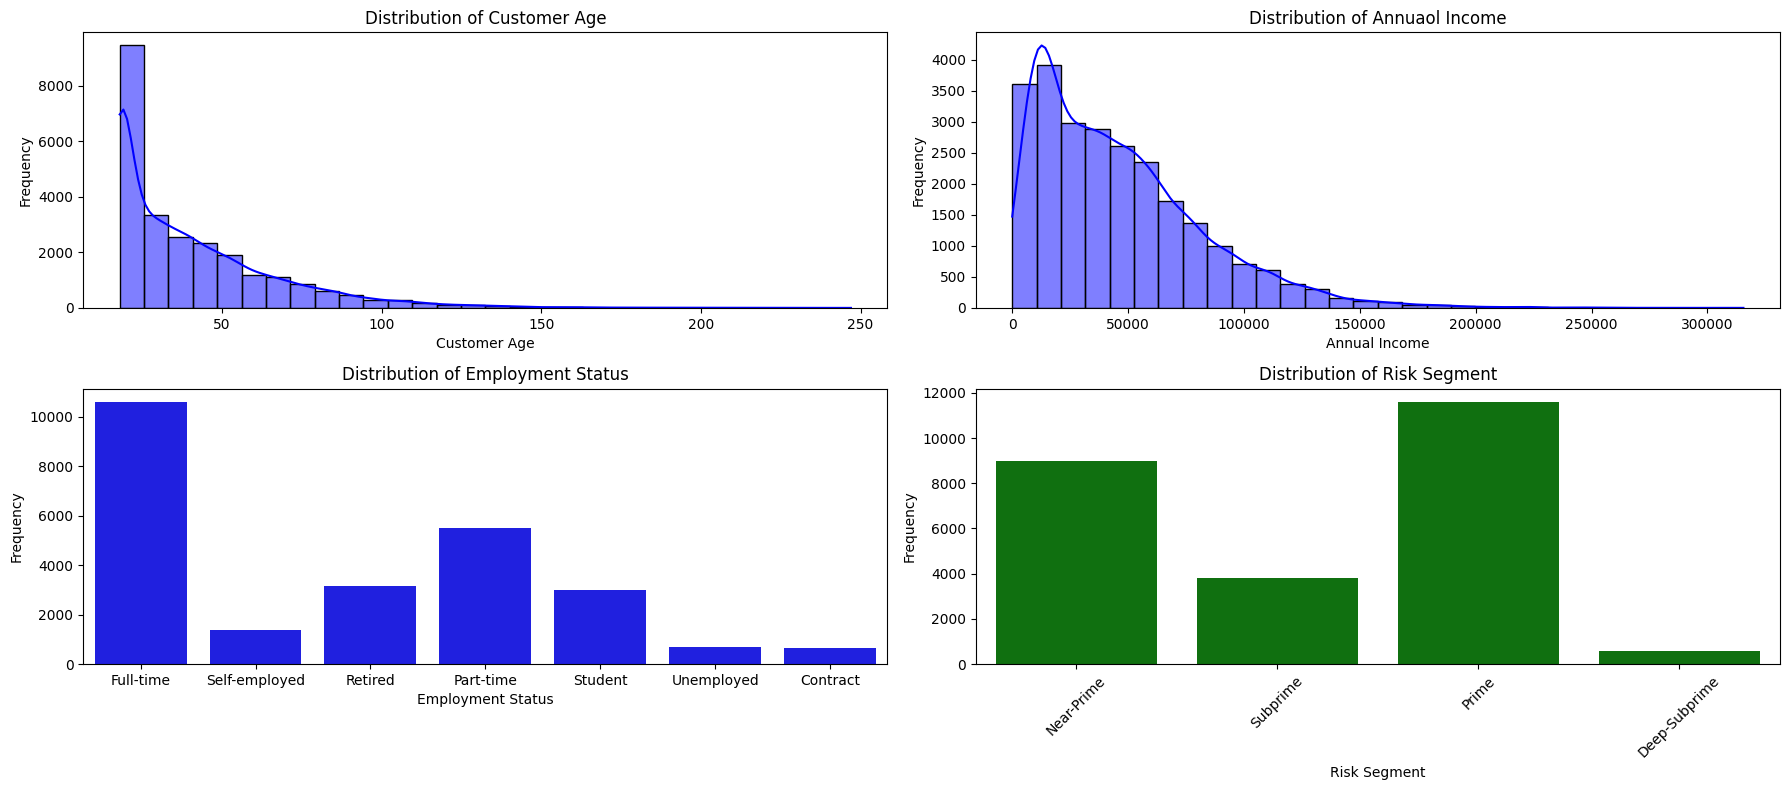

In [44]:
# Create subplots (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# 1. Annual Income
sns.histplot(customer_profiles['customer_age'].dropna(), bins=30, kde=True, color='blue', ax=axes[0,0])
axes[0,0].set_title('Distribution of Customer Age')
axes[0,0].set_xlabel('Customer Age')
axes[0,0].set_ylabel('Frequency')

# 2. 
sns.histplot(customer_profiles['annual_income'].dropna(), bins=30, kde=True, color='blue', ax=axes[0,1])
axes[0,1].set_title('Distribution of Annuaol Income')
axes[0,1].set_xlabel('Annual Income')
axes[0,1].set_ylabel('Frequency')

# 3.  
sns.countplot(x=customer_profiles['employment_status'].dropna(), color='blue', ax=axes[1,0])
axes[1,0].set_title('Distribution of Employment Status')
axes[1,0].set_xlabel('Employment Status')
axes[1,0].set_ylabel('Frequency')

# 4. 
sns.countplot(x=customer_profiles['risk_segment'].dropna(), color='green', ax=axes[1,1])
axes[1,1].set_title('Distribution of Risk Segment')
axes[1,1].set_xlabel('Risk Segment')
axes[1,1].set_ylabel('Frequency')
axes[1,1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

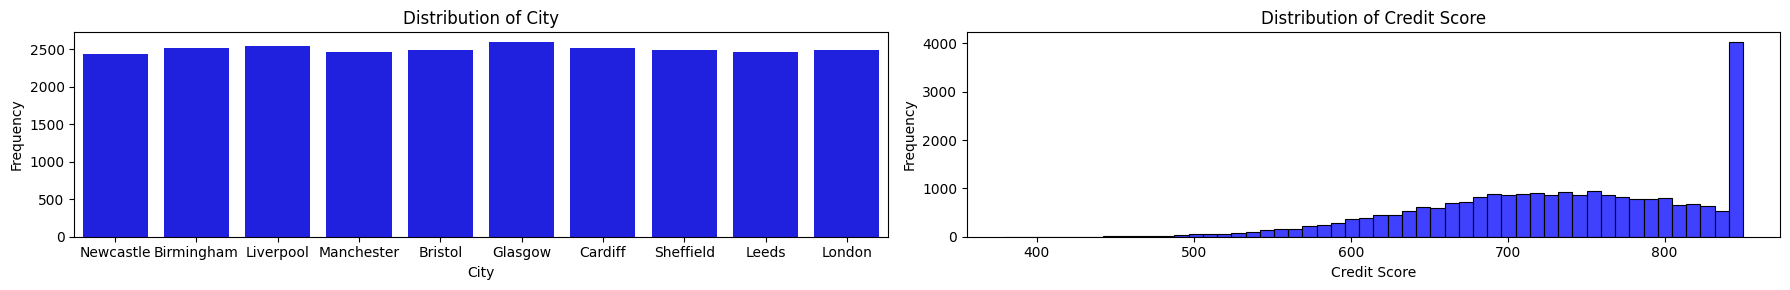

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 3))

# 1.  
sns.countplot(x=customer_profiles['city'].dropna(), color='blue', ax=axes[0])
axes[0].set_title('Distribution of City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Frequency')

# 2.  
sns.histplot(x=customer_profiles['credit_score'].dropna(), color='blue', ax=axes[1])
axes[1].set_title('Distribution of Credit Score')   
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

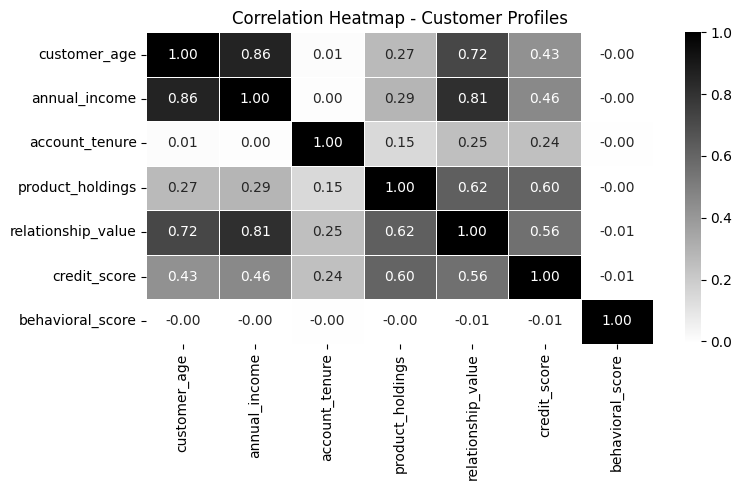

In [49]:

# Select numeric columns for correlation
corr_cols = ['customer_age', 'annual_income','account_tenure','product_holdings','relationship_value', 'credit_score', 'behavioral_score']

# Compute correlation matrix
corr = customer_profiles[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='binary', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - Customer Profiles")
plt.tight_layout()
plt.show()

### EDA for Transaction Data

In [50]:
transaction_data.head()

,transaction_id,customer_id,transaction_date,amount,merchant_category,transaction_type,location,device_info,fraud_flag,investigation_status
0,TXN_00000001,CUST_004019,2024-03-25 11:24:31,34.85,Groceries,Purchase,Manchester,Mobile,0,Not Investigated
1,TXN_00000002,CUST_000222,2022-05-24 14:21:01,84.32,Fuel,Purchase,Bristol,Mobile,0,Not Investigated
2,TXN_00000003,CUST_007895,2023-01-15 10:15:41,6.82,Fuel,Purchase,London,Chip,0,Not Investigated
3,TXN_00000004,CUST_021148,2023-10-03 06:15:45,59.90,Groceries,Purchase,Birmingham,Contactless,0,Not Investigated
4,TXN_00000005,CUST_016591,2024-11-24 09:09:02,71.01,Transfer,Transfer,Leeds,Desktop,0,Not Investigated


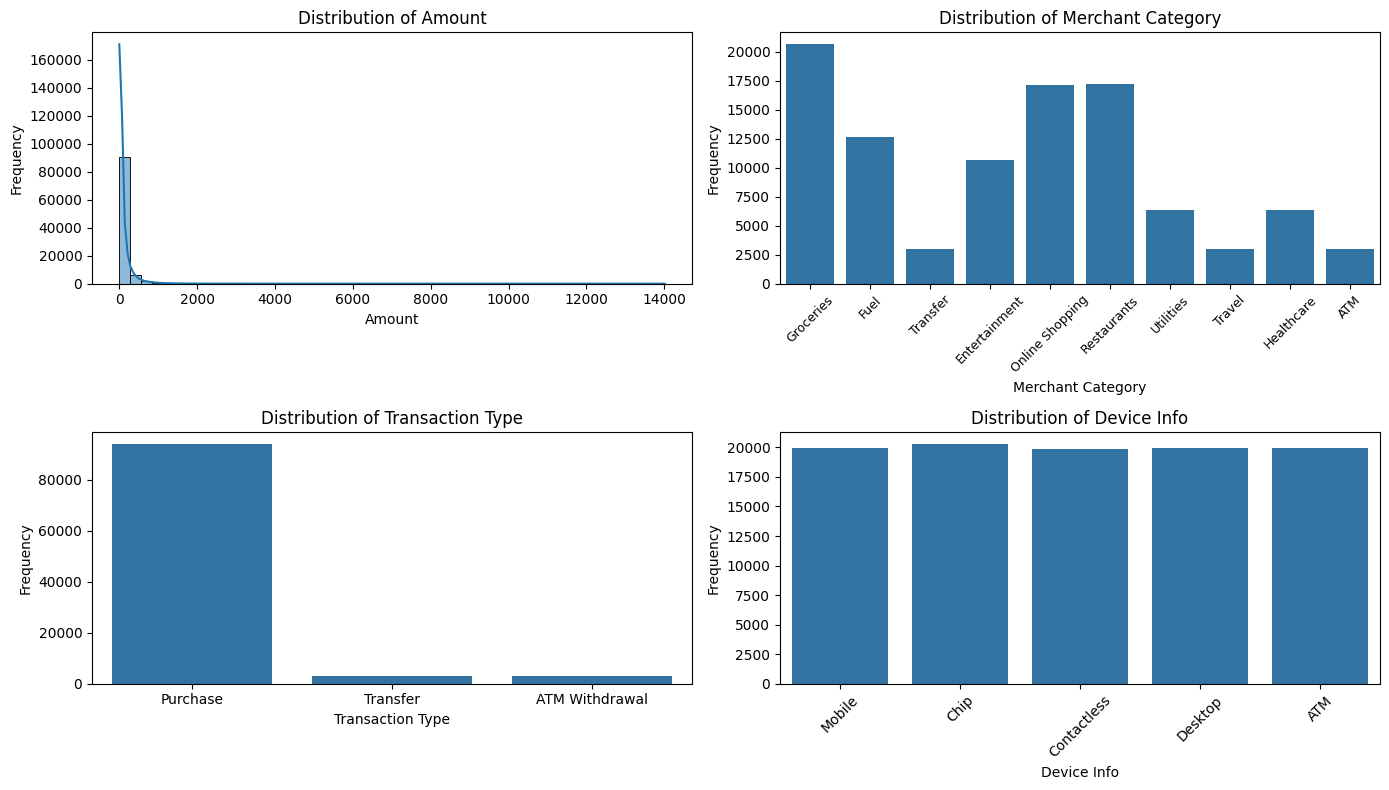

In [53]:
# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Distribution of Amount
sns.histplot(data=transaction_data, x='amount', bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Amount')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

# 2) Distribution of Merchant Category
sns.countplot(data=transaction_data, x='merchant_category', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Merchant Category')
axes[0, 1].set_xlabel('Merchant Category')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=9)

# 3) Distribution of Transaction Type
sns.countplot(data=transaction_data, x='transaction_type', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Transaction Type')
axes[1, 0].set_xlabel('Transaction Type')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4) Distribution of Device Info
sns.countplot(data=transaction_data, x='device_info', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Device Info')
axes[1, 1].set_xlabel('Device Info')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

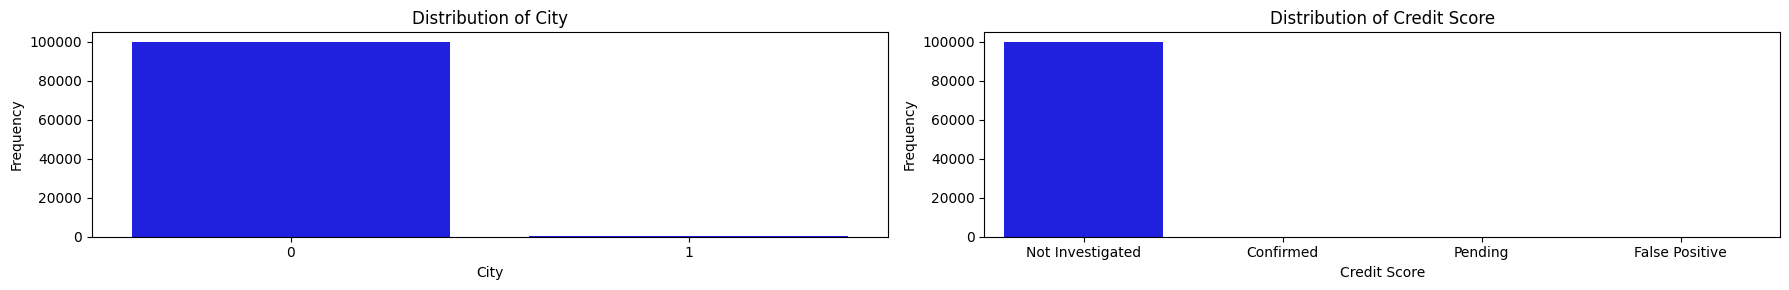

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(18, 3))

# 1.  
sns.countplot(x= transaction_data['fraud_flag'].dropna(), color='blue', ax=axes[0])
axes[0].set_title('Distribution of City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Frequency')

# 2.  
sns.countplot(x= transaction_data['investigation_status'].dropna(), color='blue', ax=axes[1])
axes[1].set_title('Distribution of Credit Score')   
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## NEXT Phase

In [59]:
# waiting for the next phase